# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [7]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [9]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [10]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [11]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [12]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [15]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [16]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [17]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [18]:
# cantidad de nulos para users

print("Cantidad de valores nulos")
print(users.isna().sum())

print("\nProporción de valores nulos")
print(users.isna().mean())

Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [19]:
# cantidad de nulos para usage

print("Cantidad de valores nulos")
print(usage.isna().sum())

print("\nProporción de valores nulos")
print(usage.isna().mean())

Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).

En el dataset users, se observa que la columna city presenta un 11.73% de valores nulos, por lo que se recomienda investigar la causa de los datos faltantes y evaluar si es conveniente imputarlos o mantenerlos como nulos, ya que este porcentaje es moderado y podría influir en análisis por ubicación. En la columna churn_date se observa un 88.35% de valores nulos; sin embargo, estos probablemente corresponden a clientes que aún no han cancelado el servicio, por lo que no se recomienda imputarlos ni eliminar la columna sin antes confirmar su significado en el contexto del negocio. En el dataset usage, la columna date presenta solo un 0.13% de valores nulos, por lo que se recomienda imputar o eliminar esos pocos registros debido a su bajo impacto. Por otra parte, las columnas duration (55.19%) y length (44.74%) muestran una alta proporción de valores nulos, pero antes de tratarlos como un problema de calidad es necesario verificar si están relacionados con la columna type, ya que es posible que la duración solo aplique a las llamadas y la longitud únicamente a los mensajes; de ser así, estos valores faltantes serían esperados y no requerirían imputación.


* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

En el dataset users, las columnas con valores faltantes son city, con un 11.73% de valores nulos, y churn_date, con un 88.35% de valores nulos. En el dataset usage, las columnas con valores faltantes son date, con un 0.13% de valores nulos, duration, con un 55.19%, y length, con un 44.74%. El resto de las columnas de ambos datasets no presentan valores faltantes.
 
- Indica qué harías: ¿imputar, eliminar, ignorar?

Para la columna city, se recomienda investigar e imputar los valores faltantes si son necesarios para el análisis, ya que presenta una proporción moderada de nulos. En churn_date, no se recomienda imputar ni eliminar la columna de inmediato, pues es probable que los valores nulos indiquen que el cliente aún no ha cancelado el servicio. En date, debido a que el porcentaje de nulos es muy bajo, se pueden imputar o eliminar esos pocos registros sin afectar significativamente el análisis. Finalmente, en duration y length, se recomienda investigar la relación con la columna type antes de tomar una decisión, ya que es posible que estos valores nulos sean esperados y dependan de si el registro corresponde a una llamada o a un mensaje.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [20]:
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna user_id contiene 4.000 registros con identificadores consecutivos entre 10000 y 13999. No se observan valores negativos ni fuera del rango esperado, por lo que no hay indicios de valores inválidos o sentinela. Al tratarse de un identificador único, esta columna no aporta información estadística para el análisis del comportamiento de los usuarios.
- La columna `age` presenta un valor mínimo de -999, el cual es un valor imposible para una edad y probablemente corresponde a un valor sentinela utilizado para representar un dato faltante. Este valor también afecta las estadísticas descriptivas, ya que hace que la media (33.74) sea menor que la mediana (47) y genera una desviación estándar muy alta (123.23), lo cual indica que existe un dato atípico que debe corregirse antes de realizar el análisis. Se recomienda reemplazar -999 por NaN y posteriormente decidir una estrategia de imputación o tratamiento de los valores faltantes.

In [21]:
# explorar columnas numéricas de usage

usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


-Las columnas id y user_id contienen identificadores de los registros y de los usuarios, respectivamente. Sus valores se encuentran dentro de rangos esperados (id de 1 a 40000 y user_id de 10000 a 13999), sin evidencias de valores negativos o sentinela. No se observa la necesidad de realizar acciones de limpieza sobre estas columnas.
-La columna duration presenta una duración mínima de 0 minutos y una máxima de 120 minutos. No se identifican valores negativos ni sentinela; sin embargo, la existencia de registros con duración igual a 0 debe revisarse para confirmar si corresponden a llamadas no contestadas o registros válidos del sistema. Además, se observa que la mayoría de las llamadas tienen una duración relativamente baja (mediana de 3.5 minutos).
-La columna length tiene valores entre 0 y 1490 caracteres. No se observan valores negativos ni sentinela, aunque los mensajes con longitud 0 deberían investigarse para verificar si corresponden a mensajes vacíos o errores de registro. También se aprecia una gran dispersión en la longitud de los mensajes, ya que el valor máximo (1490) es considerablemente superior a la mediana (50), lo que podría indicar la presencia de valores atípicos que será conveniente analizar en etapas posteriores mediante boxplots o el método del IQR.

In [22]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f"\nValores únicos de {columna}:")
    print(users[columna].value_counts(dropna=False))


Valores únicos de city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` presenta varias ciudades válidas (Bogotá, CDMX, Medellín, GDL, Cali y MTY), pero también contiene 469 valores nulos y 96 registros con el valor "?", lo que indica la presencia de un valor inválido o sentinela utilizado para representar información desconocida. Se recomienda reemplazar "?" por NaN y posteriormente evaluar si es conveniente imputar los valores faltantes o mantenerlos como nulos, dependiendo del análisis.
- La columna `plan` únicamente contiene las categorías "Basico" y "Premium", sin valores nulos ni categorías inesperadas. Esto indica que la variable está correctamente estandarizada y no requiere limpieza adicional.

In [23]:
# explorar columna categórica de usage

usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` contiene únicamente dos categorías: text (22.092 registros) y call (17.908 registros). No se observan valores nulos ni categorías inesperadas, por lo que la variable está correctamente estandarizada y no presenta valores inválidos o sentinela. Además, estas categorías son coherentes con el objetivo del análisis, ya que representan los dos tipos de uso del servicio de telecomunicaciones (mensajes y llamadas).
La presencia exclusiva de las categorías call y text también ayuda a explicar los valores nulos encontrados anteriormente en las columnas duration y length. Es probable que los registros de tipo call no tengan longitud del mensaje (length), mientras que los registros de tipo text no tengan duración (duration). Por ello, estos valores nulos podrían formar parte del diseño del dataset y no representar un problema de calidad de los datos. Esta hipótesis deberá confirmarse en los siguientes pasos del análisis.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

Durante la revisión de la calidad de los datos se identificaron algunos aspectos que requieren tratamiento antes de continuar con el análisis. En el dataset users, la columna age contiene el valor -999, el cual corresponde a un valor sentinela y debe reemplazarse por NaN para evitar sesgos en las estadísticas. La columna city presenta valores nulos y registros con el valor "?", por lo que se recomienda reemplazar este último por NaN y posteriormente evaluar una estrategia de imputación o mantener los valores faltantes según el objetivo del análisis. La columna plan no presenta inconsistencias y solo contiene las categorías esperadas (Basico y Premium). En el dataset usage, las columnas id, user_id y type no muestran valores inválidos y la columna type únicamente contiene las categorías call y text, lo que indica que está correctamente estandarizada. Asimismo, los valores nulos observados en duration y length probablemente se explican por el tipo de registro (llamadas o mensajes), por lo que antes de imputarlos se recomienda verificar esta relación para confirmar que corresponden al diseño del dataset y no a errores de calidad. Finalmente, los valores mínimos de 0 en duration y length deben revisarse para confirmar si representan registros válidos, como llamadas no contestadas o mensajes vacíos.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

  Se encontraron valores inválidos o sentinels en el dataset users. La columna age contiene el valor -999, el cual no representa una edad válida y corresponde a un valor sentinela. Asimismo, la columna city presenta registros con el valor "?", además de valores nulos, lo que indica información faltante o desconocida. En las demás columnas analizadas (plan, id, user_id y type) no se identificaron valores inválidos ni categorías inesperadas.

- ¿Qué acción tomarías?

  Se recomienda reemplazar los valores sentinela (-999 en age y "?" en city) por NaN, para tratarlos como valores faltantes durante la limpieza de datos. Posteriormente, se debe evaluar si estos valores se imputan o se mantienen como nulos según el análisis y el impacto que tengan en el estudio. En las columnas que no presentan inconsistencias no es necesario realizar ninguna acción, ya que sus valores son válidos y se encuentran correctamente estandarizados.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [24]:

# Convertir a fecha la columna `reg_date` de users

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [25]:
# Convertir a fecha la columna `date` de usage

usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [26]:

# Revisar los años presentes en `reg_date` de users

print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`se observa que la mayoría de los registros corresponden a los años 2022, 2023 y 2024, los cuales están dentro del rango esperado para el análisis. Sin embargo, se identificaron 40 registros con el año 2026, lo que representa una fecha fuera del rango definido por el proyecto y sugiere un posible error de captura o de calidad de los datos. Se recomienda revisar estos registros y corregirlos o excluirlos del análisis si no es posible validar la fecha correcta.

In [28]:
# Revisar los años presentes en `date` de usage

print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`se observa que todos los registros válidos corresponden al año 2024, por lo que las fechas se encuentran dentro del rango esperado para el análisis. No se identifican años futuros ni valores fuera del periodo establecido, por lo que no es necesario realizar correcciones relacionadas con el año de esta variable.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

Después de revisar las columnas de fechas, se encontró que la mayoría de los registros se encuentran dentro del rango esperado (2022, 2023 y 2024). Sin embargo, en la columna reg_date se identificaron 40 registros correspondientes al año 2026, lo que representa una fecha fuera del periodo de análisis y sugiere un posible error de captura o registro. En la columna date, todos los registros válidos pertenecen al año 2024, por lo que no se detectaron inconsistencias. Se recomienda revisar los registros con fecha en 2026 y, si no es posible validar su información, corregirlos o excluirlos del análisis para evitar sesgos en los resultados. No es necesario realizar acciones sobre la columna date, ya que sus fechas son consistentes con el periodo de estudio.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  En la columna reg_date se observa que la mayoría de los registros corresponden a los años 2022, 2023 y 2024, los cuales están dentro del rango esperado. Sin embargo, se identificaron 40 registros del año 2026, lo que representa un año futuro respecto al periodo de análisis y sugiere un posible error de captura o registro. En la columna date, todos los registros válidos corresponden al año 2024, por lo que no se encontraron fechas fuera del rango esperado.
- ¿Qué harías con ellas?
  Se recomienda investigar los 40 registros del año 2026 para verificar si corresponden a un error de digitación o de captura. Si no es posible confirmar la fecha correcta, estos registros deberían corregirse o excluirse del análisis para evitar sesgos en los resultados. En cuanto a la columna date, no es necesario realizar ninguna acción, ya que todas las fechas se encuentran dentro del periodo esperado y son consistentes con el contexto del proyecto.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [29]:

# Reemplazar -999 por la mediana de age

# Calculamos la mediana ignorando el sentinel -999
age_mediana = users.loc[users['age'] != -999, 'age'].median()

# Reemplazamos el sentinel por la mediana
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [30]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()

565

In [32]:


# Marcar fechas futuras como NaT para reg_date

# Nos aseguramos de que la columna esté en formato datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Definimos "hoy" como límite superior válido
hoy = pd.Timestamp.today()

# Marcamos como NaT cualquier fecha futura (fuera de rango)
users.loc[users['reg_date'] > hoy, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

0

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [33]:

# Verificación MAR en usage (Missing At Random) para duration

# Proporción de nulos en duration, agrupado por type
nulos_duration_por_type = usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())
print(nulos_duration_por_type)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [34]:

# Verificación MAR en usage (Missing At Random) para length

# Proporción de nulos en length, agrupado por type
nulos_length_por_type = usage.groupby('type')['length'].apply(lambda x: x.isna().mean())
print(nulos_length_por_type)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Los nulos en duration y length son MAR (Missing At Random), ya que su proporción depende claramente de la columna type.

En duration, el tipo call no tiene nulos (0%), mientras que el tipo text tiene casi el 100% de nulos (99.93%).
En length, ocurre justo lo contrario: call tiene casi el 100% de nulos (99.93%) y text no tiene nulos (0%).

Este patrón tiene sentido lógico: duration (duración de la llamada) solo aplica a registros de tipo call, y length (longitud del mensaje) solo aplica a registros de tipo text. Es decir, los nulos no son aleatorios en sí mismos, sino que están totalmente explicados por la categoría a la que pertenece cada registro.
Por esta razón, se dejan los nulos como están, sin imputarlos. Rellenarlos (por ejemplo, con la media o mediana) generaría valores sin sentido, como asignarle una "duración de llamada" a un mensaje de texto, y ocultaría una relación estructural real de los datos en lugar de un problema de calidad.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [35]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [36]:
# Renombrar columnas
# (Ya se asignaron los nombres correctos en el agg de la celda anterior:
# cant_mensajes, cant_llamadas, cant_minutos_llamada)

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [39]:

# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [40]:

# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

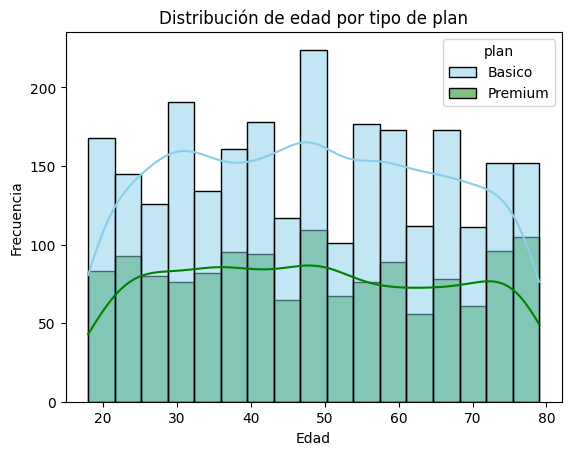

In [41]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
-Distribución general: La edad de los usuarios está bien distribuida entre los 20 y los 80 años, sin una concentración marcada en un rango específico — es decir, la plataforma tiene usuarios de todas las edades de forma relativamente pareja.

-Plan Básico: Tiene una distribución aproximadamente simétrica (casi normal), con una leve concentración alrededor de los 45-50 años, donde se ve el pico más alto (más de 200 usuarios). El plan Básico domina claramente en volumen sobre el Premium en casi todos los rangos de edad.

-Plan Premium: Su distribución es más plana/uniforme a lo largo de todo el rango de edad, sin picos muy pronunciados, aunque se nota un leve aumento entre los 30-40 años y otro pequeño repunte cerca de los 70-75 años.
Comparación entre planes: No hay evidencia de que un plan esté asociado a un grupo etario específico (por ejemplo, no se observa que los jóvenes prefieran Premium y los mayores Básico, ni viceversa). Ambos planes coexisten en todos los rangos de edad, aunque el Básico tiene una base de usuarios notablemente mayor en términos absolutos.

-Tipo de distribución: La curva del plan Básico se asemeja a una distribución ligeramente sesgada hacia la izquierda (cola más corta a la derecha), con su pico cerca de los 45-50 años. La curva de Premium es más uniforme/plana, sin un sesgo claro.

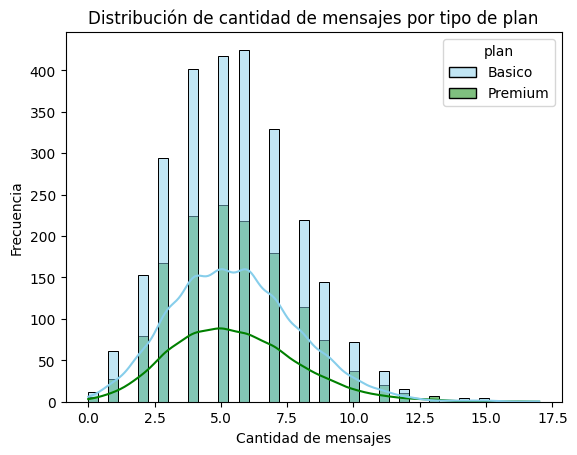

In [42]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

-Distribución general: La cantidad de mensajes tiene una distribución sesgada hacia la derecha (right-skewed), con la mayoría de los usuarios enviando entre 2.5 y 7.5 mensajes, y una cola larga que se extiende hasta 17.5 mensajes con muy pocos usuarios en ese extremo.

-Plan Básico: Concentra el mayor volumen de usuarios en el rango de 4 a 6 mensajes, con el pico más alto cerca de los 6 mensajes (más de 400 usuarios). Domina claramente en frecuencia sobre el plan Premium en casi todo el rango.

-Plan Premium: Sigue un patrón similar al Básico pero con menor volumen total; su pico también se ubica alrededor de 4-6 mensajes, aunque su curva es más plana y con menos usuarios en los extremos (tanto en valores bajos como altos).

-Comparación entre planes: No se observa que un plan tienda a enviar sustancialmente más o menos mensajes que el otro en proporción — ambos muestran la misma forma general de distribución, solo que el plan Básico tiene mayor cantidad absoluta de usuarios en casi todos los tramos.

-Tipo de distribución: Es una distribución asimétrica positiva (sesgada a la derecha), típica de variables de conteo donde la mayoría de los valores se agrupan en un rango bajo-medio y solo unos pocos usuarios envían una cantidad muy alta de mensajes (outliers en la cola derecha).

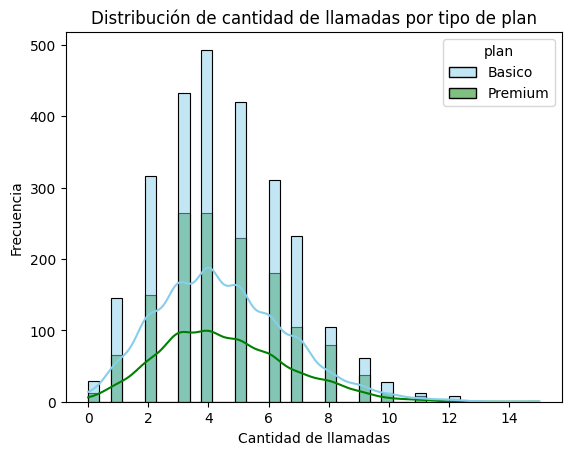

In [43]:

# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución general: La cantidad de llamadas presenta una distribución sesgada hacia la derecha (right-skewed), con la mayoría de los usuarios realizando entre 3 y 6 llamadas, y una cola larga que se extiende hasta 14-15 llamadas con muy pocos usuarios en ese extremo.

-Plan Básico: Concentra el mayor volumen, con su pico más alto cerca de 4 llamadas (casi 500 usuarios). Domina de forma clara sobre el plan Premium en todo el rango, especialmente entre 3 y 6 llamadas.
-Plan Premium: Sigue la misma forma general que el Básico, con su pico también alrededor de 3-4 llamadas, pero con un volumen considerablemente menor (poco más de 100 usuarios en su punto máximo). No hay una tendencia diferente en la forma, solo en la magnitud.

-Comparación entre planes: Al igual que con cant_mensajes, no hay evidencia de que un plan favorezca hacer más o menos llamadas en proporción — ambas curvas (línea azul clara y verde) tienen prácticamente la misma forma, solo que desplazadas en escala por la diferencia en cantidad de usuarios de cada plan.

-Tipo de distribución: Es una distribución asimétrica positiva (sesgada a la derecha), consistente con el patrón ya visto en mensajes: la mayoría de los usuarios se agrupan en un rango bajo-medio de llamadas, y solo unos pocos hacen un número mucho más alto (posibles outliers en la cola derecha).

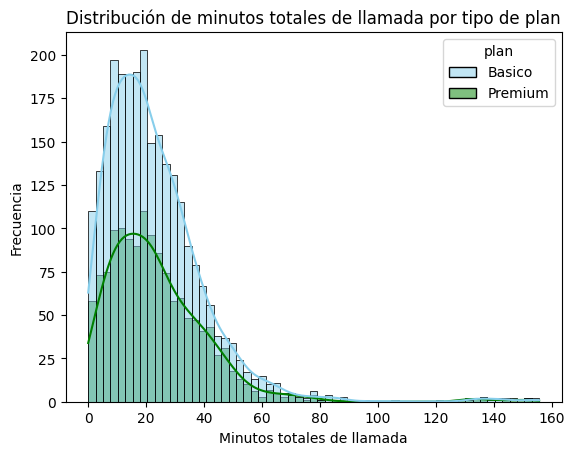

In [44]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de minutos totales de llamada por tipo de plan')
plt.xlabel('Minutos totales de llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
-Distribución general: Los minutos totales de llamada presentan una distribución fuertemente sesgada hacia la derecha (right-skewed), con la mayoría de los usuarios concentrados entre 0 y 40 minutos, y una cola larga y delgada que se extiende hasta 160 minutos con muy pocos usuarios ahí.

-Plan Básico: Tiene el pico más alto alrededor de 10-15 minutos (cerca de 200 usuarios), y su curva desciende de forma pronunciada a medida que aumentan los minutos. Domina claramente en volumen sobre el Premium en todo el rango.

-Plan Premium: Sigue la misma forma general, con su pico también cerca de 15-20 minutos, pero con una magnitud bastante menor (poco menos de 100 usuarios en su punto máximo). Se nota que su curva es un poco más ancha y desplazada levemente a la derecha respecto al Básico, sugiriendo que los usuarios Premium podrían tener llamadas ligeramente más largas en promedio.

-Comparación entre planes: No hay una diferencia drástica en el comportamiento — ambos planes muestran el mismo patrón de concentración en minutos bajos y una cola de pocos usuarios con consumo alto. La diferencia principal sigue siendo de volumen (más usuarios Básico) más que de patrón de uso.

-Tipo de distribución: Es una distribución asimétrica positiva marcada (sesgada a la derecha), la más pronunciada de las cuatro variables analizadas hasta ahora — hay incluso una pequeña "meseta" cerca de 130-150 minutos, que podría representar un grupo pequeño de usuarios con un patrón de uso muy distinto (posibles outliers o un segmento de usuarios de alto consumo).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

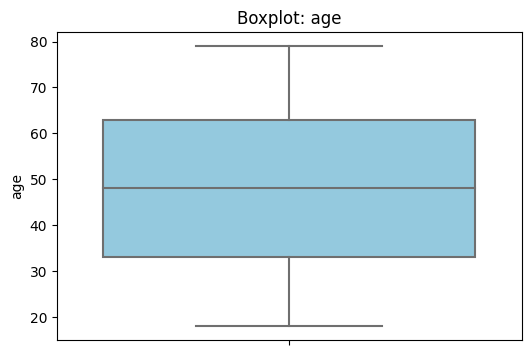

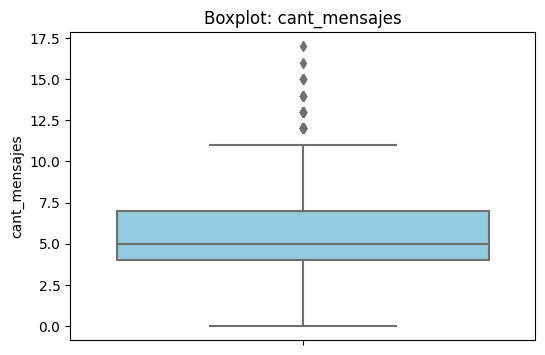

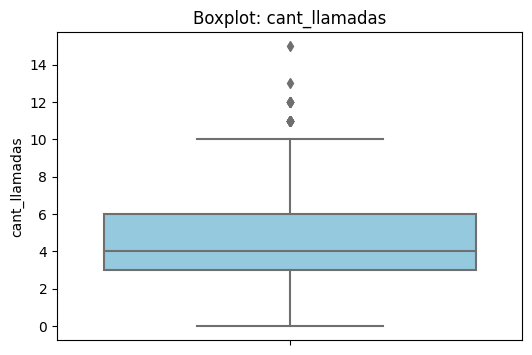

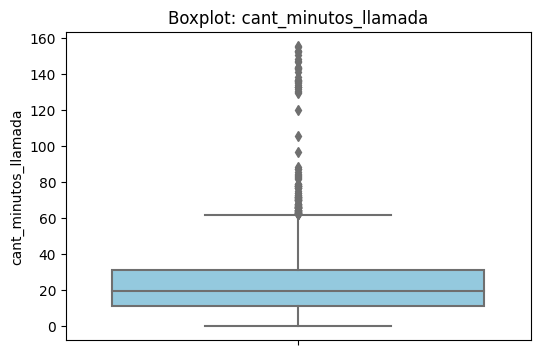

In [45]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, y=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()

💡Insights: 

-Age: No presenta outliers. El boxplot muestra una distribución simétrica y compacta (bigotes limpios, sin puntos fuera de rango), consistente con lo que ya vimos en el histograma.

-cant_mensajes: Sí presenta outliers, todos en el lado superior (valores por encima de ~11 mensajes, llegando hasta cerca de 17.5). No hay outliers en el lado inferior, ya que el valor mínimo posible es 0.

-cant_llamadas: Sí presenta outliers, también solo en el lado superior (valores por encima de ~10 llamadas, llegando hasta cerca de 15). Igual que en mensajes, no aplica límite inferior porque no puede haber llamadas negativas.

-cant_minutos_llamada: Es la variable con más outliers y más extremos, todos en el lado superior (por encima de ~62 minutos aproximadamente, con varios puntos dispersos hasta 160 minutos). Es la distribución más sesgada de las cuatro, confirmando lo que ya se veía en su histograma.

*Conclusión general*: Solo age no tiene outliers. En cant_mensajes, cant_llamadas y cant_minutos_llamada los outliers están únicamente del lado superior — por lo tanto, en el siguiente paso (cálculo de límites IQR) solo necesitas calcular el límite superior para estas tres columnas, no el inferior.

In [46]:
# Calcular límites con el método IQR
columnas_limites = {}

for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    columnas_limites[col] = {
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    }

columnas_limites

{'age': {'limite_inferior': -12.0, 'limite_superior': 108.0},
 'cant_mensajes': {'limite_inferior': -0.5, 'limite_superior': 11.5},
 'cant_llamadas': {'limite_inferior': -1.5, 'limite_superior': 10.5},
 'cant_minutos_llamada': {'limite_inferior': -19.322500000000005,
  'limite_superior': 61.8575}}

In [47]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 

-cant_mensajes: Se recomienda mantener los outliers. No son errores de captura, son usuarios que simplemente envían más mensajes de lo habitual — es un comportamiento de uso real y plausible (el máximo de 17 no es un valor absurdo para una persona muy activa).

-cant_llamadas: Se recomienda mantener los outliers, por la misma razón: 15 llamadas no es un valor imposible ni indica error de datos, solo representa usuarios con mayor actividad telefónica.

-cant_minutos_llamada: Se recomienda mantener los outliers también. Aunque es la variable con la desviación más amplia (hasta 155.69 minutos), sigue siendo un valor razonable para una llamada o acumulado de llamadas de un usuario con alto consumo — no hay evidencia de que sean errores de digitación (como sí lo sería, por ejemplo, un valor negativo o de miles de minutos).

Justificación general: En las tres variables, los outliers representan variabilidad natural del comportamiento del usuario (algunos usuarios simplemente usan más el servicio), no errores de captura de datos. Eliminarlos reduciría información válida sobre el segmento de usuarios de alto consumo, lo cual podría ser justo el grupo de interés para análisis de negocio (por ejemplo, identificar candidatos a upgrade de plan). Por eso la recomendación es no eliminar los outliers, sino tenerlos en cuenta como parte del análisis.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [48]:
# Crear columna grupo_uso

def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [49]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [50]:
# Crear columna grupo_edad

def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [51]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

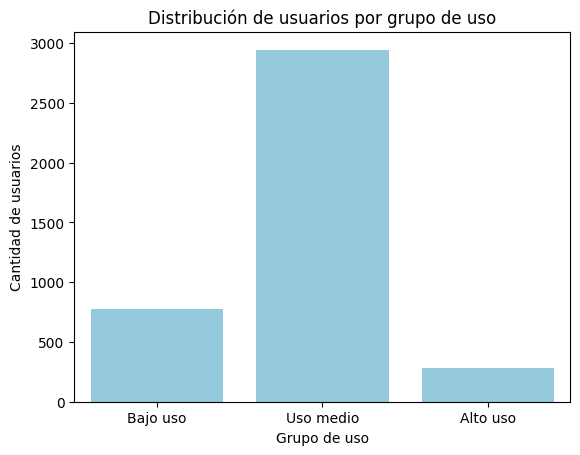

In [52]:

# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], color='skyblue')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

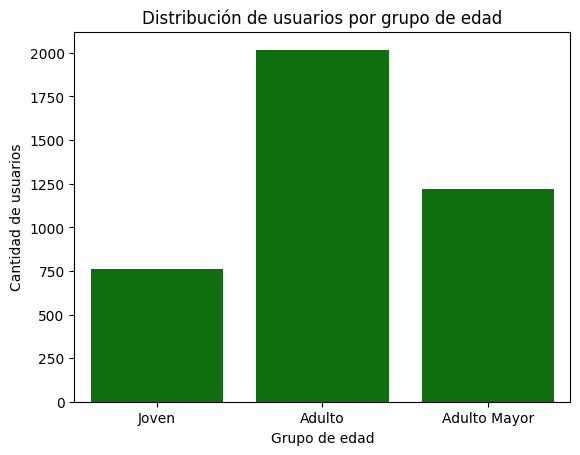

In [53]:

# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], color='green')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

Durante la etapa de limpieza se identificaron varios problemas de calidad en los datos: la columna age contenía el valor sentinela -999, que distorsionaba las estadísticas descriptivas y fue corregido con la mediana; city presentaba 565 registros sin ciudad válida (14.1% del total, entre nulos y valores "?"); y reg_date incluía 40 registros (1%) con fechas de 2026, fuera del periodo de análisis, los cuales se marcaron como nulos. A partir de los datos ya limpios se identificaron dos ejes de segmentación: por edad (Joven, Adulto y Adulto Mayor, distribuidos de forma pareja y sin relación clara con el tipo de plan) y por nivel de uso (Bajo, Medio y Alto uso, según llamadas y mensajes), donde la mayoría de los clientes se concentra en los niveles de uso bajo y medio. El segmento de Alto uso, particularmente los usuarios adultos dentro de este grupo, resulta el más valioso para ConnectaTel, ya que su comportamiento de consumo indica que están cerca de o superan los límites de su plan actual, generando ingresos adicionales por cargos extra o representando candidatos naturales a un upgrade a Premium. Este mismo grupo concentra los patrones de uso extremo detectados en cant_mensajes, cant_llamadas y especialmente en cant_minutos_llamada (hasta 155.69 minutos), outliers que se decidió mantener en el análisis por tratarse de comportamiento real y no de errores de captura, y que constituyen una señal comercial relevante en lugar de ruido a descartar. Con base en estos hallazgos, se recomienda crear un plan intermedio entre Básico y Premium orientado al segmento de uso medio, dirigir campañas de upgrade específicamente al segmento de alto uso, reforzar la validación de datos en el proceso de registro de usuarios para prevenir errores similares a futuro, y priorizar el nivel de uso —más que la edad— como criterio principal de segmentación comercial.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

-En age, se encontró el valor sentinela -999, que distorsionaba las estadísticas (media de 33.74 años frente a una mediana de 47, con desviación estándar anómala de 123.23). Se corrigió reemplazándolo por la mediana.

-En city, había 565 registros sin ciudad válida (14.1% del total): 469 nulos originales más 96 registros con "?". Se estandarizaron todos como nulos.

-En reg_date, se detectaron 40 registros (1%) con fecha de 2026, fuera del periodo de análisis (2022-2024). Se marcaron como nulos por ser un error de captura.
Los nulos en duration y length (~99.9% cada uno) no representan un problema real, sino una relación estructural con el tipo de registro (call vs text), por lo que se dejaron sin imputar.

🔍 **Segmentos por Edad**

-Se crearon tres grupos: Joven (<30), Adulto (30-59) y Adulto Mayor (60+), distribuidos de forma relativamente pareja entre sí.

-No se encontró relación clara entre la edad y el tipo de plan contratado: tanto el Básico como el Premium tienen usuarios en todos los rangos de edad.

📊 **Segmentos por Nivel de Uso**

- Se crearon tres grupos: Bajo uso, Uso medio y Alto uso, según cantidad de llamadas y mensajes.

-La mayoría de los clientes se concentra en los niveles de Bajo y Medio uso, dado que las medias de mensajes (5.5) y llamadas (4.5) son bajas frente a los máximos observados (17 y 15 respectivamente).

-El grupo de Alto uso, aunque más reducido, concentra a los usuarios con comportamiento de consumo más intenso, incluyendo los outliers detectados en mensajes, llamadas y minutos de llamada (hasta 155.69 minutos).


➡️ Esto sugiere que ConnectaTel tiene una base de clientes mayormente estable y de consumo moderado, con un segmento minoritario pero comercialmente valioso de usuarios de alto consumo (particularmente adultos dentro de ese grupo), quienes probablemente ya están pagando cargos extra en el plan Básico o subutilizando los beneficios de un Premium mal ajustado a su comportamiento real. Este mismo segmento es el que concentra los patrones de uso extremo, los cuales no deben tratarse como ruido a eliminar sino como una señal comercial de oportunidad de upgrade.


💡 **Recomendaciones**
- Crear un plan intermedio entre Básico y Premium dirigido al segmento de "Uso medio", que probablemente enfrenta cargos extra recurrentes.

-Dirigir campañas de upgrade a Premium específicamente al segmento de Alto uso, priorizando a los adultos dentro de ese grupo.

-Reforzar la validación de datos en el proceso de registro (edad, ciudad, fecha), ya que los errores encontrados sugieren fallas en el formulario de alta más que ruido aleatorio.
Priorizar el nivel de uso, no la edad, como criterio principal de segmentación comercial, dado que no se encontró relación entre edad y tipo de plan.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`